# EfficientNet-B0 for Diabetic Retinopathy Classification

This notebook trains and evaluates EfficientNet-B0 on a 5-class Diabetic Retinopathy dataset with explainability using Grad-CAM++ and LIME.


## 1. Setup & Installs


In [25]:
# Check GPU availability (commented out for local MacBook - no NVIDIA GPU)
# !nvidia-smi
print("Running on local MacBook Pro")


Error in callback <bound method _WandbInit._pre_run_cell_hook of <wandb.sdk.wandb_init._WandbInit object at 0x357ddef90>> (for pre_run_cell), with arguments args (<ExecutionInfo object at 3568c6f90, raw_cell="# Check GPU availability (commented out for local .." transformed_cell="# Check GPU availability (commented out for local .." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell:/Users/smridhipatwari/Projects/retinxplain/Notebooks/efficientnet_b0_RetinXplain_cleaned.ipynb#W2sZmlsZQ%3D%3D>,),kwargs {}:


BrokenPipeError: [Errno 32] Broken pipe

socket.send() raised exception.


Running on local MacBook Pro
Error in callback <bound method _WandbInit._post_run_cell_hook of <wandb.sdk.wandb_init._WandbInit object at 0x357ddef90>> (for post_run_cell), with arguments args (<ExecutionResult object at 3611de7d0, execution_count=25 error_before_exec=None error_in_exec=None info=<ExecutionInfo object at 3568c6f90, raw_cell="# Check GPU availability (commented out for local .." transformed_cell="# Check GPU availability (commented out for local .." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell:/Users/smridhipatwari/Projects/retinxplain/Notebooks/efficientnet_b0_RetinXplain_cleaned.ipynb#W2sZmlsZQ%3D%3D> result=None>,),kwargs {}:


BrokenPipeError: [Errno 32] Broken pipe

In [26]:
# Install required packages
%pip install wandb grad-cam lime scikit-image -q


socket.send() raised exception.
socket.send() raised exception.


Error in callback <bound method _WandbInit._pre_run_cell_hook of <wandb.sdk.wandb_init._WandbInit object at 0x357ddef90>> (for pre_run_cell), with arguments args (<ExecutionInfo object at 3568c6dd0, raw_cell="# Install required packages
%pip install wandb gra.." transformed_cell="# Install required packages
get_ipython().run_line.." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell:/Users/smridhipatwari/Projects/retinxplain/Notebooks/efficientnet_b0_RetinXplain_cleaned.ipynb#W3sZmlsZQ%3D%3D>,),kwargs {}:


BrokenPipeError: [Errno 32] Broken pipe

^C
object address  : 0x103499ba0
object refcount : 2
object type     : 0x100f209b8
object type name: KeyboardInterrupt
object repr     : KeyboardInterrupt()
lost sys.stderr


socket.send() raised exception.
socket.send() raised exception.


Note: you may need to restart the kernel to use updated packages.
Error in callback <bound method _WandbInit._post_run_cell_hook of <wandb.sdk.wandb_init._WandbInit object at 0x357ddef90>> (for post_run_cell), with arguments args (<ExecutionResult object at 30a274150, execution_count=26 error_before_exec=None error_in_exec=None info=<ExecutionInfo object at 3568c6dd0, raw_cell="# Install required packages
%pip install wandb gra.." transformed_cell="# Install required packages
get_ipython().run_line.." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell:/Users/smridhipatwari/Projects/retinxplain/Notebooks/efficientnet_b0_RetinXplain_cleaned.ipynb#W3sZmlsZQ%3D%3D> result=None>,),kwargs {}:


BrokenPipeError: [Errno 32] Broken pipe

In [ ]:
# Suppress warnings
import warnings
warnings.filterwarnings("ignore")


## 2. Imports & Device Setup


In [ ]:
# Core Python
import os
import time
import random
import warnings
import numpy as np
import pandas as pd
from PIL import Image
import cv2
import matplotlib.pyplot as plt
import seaborn as sns

# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

# TorchVision
from torchvision import transforms
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

# Evaluation
from sklearn.metrics import confusion_matrix, classification_report, f1_score

# Explainability
from pytorch_grad_cam import GradCAMPlusPlus
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from lime import lime_image
from skimage.segmentation import mark_boundaries

# Weights & Biases
import wandb

# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"CUDA Version: {torch.version.cuda}")
print(f"PyTorch Version: {torch.__version__}")


Using device: cpu
PyTorch Version: 2.2.2


## 3. Data Paths, Loading & Cleaning


In [ ]:
# Mount Google Drive (commented out for local execution)
# from google.colab import drive
# drive.mount('/content/drive')


In [ ]:
# Data paths - using local project structure
# Get the project root directory (notebook is in Notebooks/ folder, project root is one level up)
current_dir = os.getcwd()
if current_dir.endswith('Notebooks'):
    PROJECT_ROOT = os.path.dirname(current_dir)
else:
    # If running from project root, use current directory
    PROJECT_ROOT = current_dir

APTOS_ROOT = os.path.join(PROJECT_ROOT, "data", "aptos")

print(f"Current working directory: {current_dir}")
print(f"Project root: {PROJECT_ROOT}")
print(f"APTOS data root: {APTOS_ROOT}")

# Verify data directory exists
if not os.path.exists(APTOS_ROOT):
    raise FileNotFoundError(f"Data directory not found: {APTOS_ROOT}\nPlease ensure data is in: {APTOS_ROOT}")
print(f"✓ Data directory found: {APTOS_ROOT}")


Current working directory: /Users/smridhipatwari/Projects/retinxplain/Notebooks
Project root: /Users/smridhipatwari/Projects/retinxplain
APTOS data root: /Users/smridhipatwari/Projects/retinxplain/data/aptos
✓ Data directory found: /Users/smridhipatwari/Projects/retinxplain/data/aptos


In [ ]:
# CSV paths
train_csv_path = os.path.join(APTOS_ROOT, "train.csv")
val_csv_path = os.path.join(APTOS_ROOT, "valid.csv")
test_csv_path = os.path.join(APTOS_ROOT, "test.csv")

# Image directories
train_images = os.path.join(APTOS_ROOT, "train_images")
val_images = os.path.join(APTOS_ROOT, "val_images")
test_images = os.path.join(APTOS_ROOT, "test_images")

# Load CSVs
train_df = pd.read_csv(train_csv_path)
val_df = pd.read_csv(val_csv_path)
test_df = pd.read_csv(test_csv_path)

print(f"Loaded CSVs:")
print(f"  Train: {len(train_df)} rows")
print(f"  Validation: {len(val_df)} rows")
print(f"  Test: {len(test_df)} rows")


Loaded CSVs:
  Train: 2930 rows
  Validation: 366 rows
  Test: 366 rows


In [ ]:
# Helper function to filter DataFrame by image existence
def _filter_dataframe_by_image_existence(df, image_dir):
    """Filter DataFrame to only include rows where images actually exist."""
    existing_images = []
    for img_id in df['id_code']:
        png_path = os.path.join(image_dir, f"{img_id}.png")
        jpg_path = os.path.join(image_dir, f"{img_id}.jpg")
        if os.path.exists(png_path) or os.path.exists(jpg_path):
            existing_images.append(img_id)
    return df[df['id_code'].isin(existing_images)].reset_index(drop=True)

# Filter to ensure all images exist
print("Filtering dataframes by image existence...")
train_df = _filter_dataframe_by_image_existence(train_df, train_images)
val_df = _filter_dataframe_by_image_existence(val_df, val_images)
test_df = _filter_dataframe_by_image_existence(test_df, test_images)

print(f"After filtering:")
print(f"  Train: {len(train_df)} samples")
print(f"  Validation: {len(val_df)} samples")
print(f"  Test: {len(test_df)} samples")


Filtering dataframes by image existence...
After filtering:
  Train: 2930 samples
  Validation: 366 samples
  Test: 366 samples


In [ ]:
# Class names
class_names = {
    0: "No DR",
    1: "Mild",
    2: "Moderate",
    3: "Severe",
    4: "Proliferative DR"
}

# Dataset summary
def print_dataset_summary(df, split_name):
    """Print dataset size and class distribution."""
    print(f"\n{split_name}: {len(df):5d} samples")
    counts = df["diagnosis"].value_counts().sort_index()
    for k, v in counts.items():
        print(f"  {k} ({class_names[k]:20s}): {v:5d} ({v/len(df)*100:5.2f}%)")

print("=" * 60)
print("Dataset Summary")
print("=" * 60)
print_dataset_summary(train_df, "Train")
print_dataset_summary(val_df, "Validation")
print_dataset_summary(test_df, "Test")


Dataset Summary

Train:  2930 samples
  0 (No DR               ):  1434 (48.94%)
  1 (Mild                ):   300 (10.24%)
  2 (Moderate            ):   808 (27.58%)
  3 (Severe              ):   154 ( 5.26%)
  4 (Proliferative DR    ):   234 ( 7.99%)

Validation:   366 samples
  0 (No DR               ):   172 (46.99%)
  1 (Mild                ):    40 (10.93%)
  2 (Moderate            ):   104 (28.42%)
  3 (Severe              ):    22 ( 6.01%)
  4 (Proliferative DR    ):    28 ( 7.65%)

Test:   366 samples
  0 (No DR               ):   199 (54.37%)
  1 (Mild                ):    30 ( 8.20%)
  2 (Moderate            ):    87 (23.77%)
  3 (Severe              ):    17 ( 4.64%)
  4 (Proliferative DR    ):    33 ( 9.02%)


## 4. Transforms & Preprocessing


In [ ]:
# Custom SmartFundusCrop transform
class SmartFundusCrop:
    """Crop fundus image to remove black borders and isolate retina circle."""
    def __call__(self, img):
        np_img = np.array(img)
        gray = cv2.cvtColor(np_img, cv2.COLOR_RGB2GRAY)
        
        # Threshold non-black area
        _, thresh = cv2.threshold(gray, 5, 255, cv2.THRESH_BINARY)
        coords = cv2.findNonZero(thresh)
        
        if coords is None:
            return img  # fallback to original
        
        x, y, w, h = cv2.boundingRect(coords)
        cropped = np_img[y:y+h, x:x+w]
        
        # Square crop around center
        h2, w2 = cropped.shape[:2]
        side = int(min(w2, h2) * 0.95)
        cx, cy = w2 // 2, h2 // 2
        x0, y0 = cx - side//2, cy - side//2
        square = cropped[y0:y0+side, x0:x0+side]
        
        return Image.fromarray(square)


In [ ]:
# ImageNet normalization constants
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

# Image size configuration
IMG_SIZE = 224
CROP_SIZE = 224
BATCH_SIZE = 32

# Data transforms
data_transforms = {
    "train": transforms.Compose([
        SmartFundusCrop(),
        transforms.Resize(IMG_SIZE),
        transforms.RandomResizedCrop(CROP_SIZE, scale=(0.9, 1.0), ratio=(0.95, 1.05)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(10),
        transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.05),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ]),
    
    "val": transforms.Compose([
        SmartFundusCrop(),
        transforms.Resize(IMG_SIZE),
        transforms.CenterCrop(CROP_SIZE),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ]),
    
    "test": transforms.Compose([
        SmartFundusCrop(),
        transforms.Resize(IMG_SIZE),
        transforms.CenterCrop(CROP_SIZE),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ]),
}

print("Data transforms configured:")
print(f"  Image size: {IMG_SIZE}x{IMG_SIZE}")
print(f"  Batch size: {BATCH_SIZE}")


Data transforms configured:
  Image size: 224x224
  Batch size: 32


In [ ]:
# Denormalization function for visualization
def denorm(img_tensor):
    """Undo ImageNet normalization for visualization."""
    if img_tensor.ndim == 3:
        # single image: [C, H, W]
        mean = torch.tensor(IMAGENET_MEAN, device=img_tensor.device).view(3, 1, 1)
        std = torch.tensor(IMAGENET_STD, device=img_tensor.device).view(3, 1, 1)
    elif img_tensor.ndim == 4:
        # batch: [B, C, H, W]
        mean = torch.tensor(IMAGENET_MEAN, device=img_tensor.device).view(1, 3, 1, 1)
        std = torch.tensor(IMAGENET_STD, device=img_tensor.device).view(1, 3, 1, 1)
    else:
        raise ValueError(f"Unsupported tensor shape for denorm: {img_tensor.shape}")
    return img_tensor * std + mean


## 5. Dataset & Dataloaders


In [ ]:
# FundusDataset class
class FundusDataset(Dataset):
    """Diabetic Retinopathy Fundus Image Dataset."""
    
    def __init__(self, df, root_dir, transform=None):
        """
        Args:
            df: DataFrame with 'id_code' and 'diagnosis' columns
            root_dir: Directory with all the images
            transform: Optional transform to apply on an image
        """
        self.labels_frame = df.reset_index(drop=True)
        self.root_dir = root_dir
        self.transform = transform
    
    def __len__(self):
        return len(self.labels_frame)
    
    def __getitem__(self, idx):
        if torch.is_tensor(idx):
            idx = idx.tolist()
        
        img_id = str(self.labels_frame.iloc[idx]['id_code'])
        label = int(self.labels_frame.iloc[idx]['diagnosis'])
        
        # Try PNG first, then JPG
        img_path = os.path.join(self.root_dir, f"{img_id}.png")
        if not os.path.exists(img_path):
            img_path = os.path.join(self.root_dir, f"{img_id}.jpg")
        if not os.path.exists(img_path):
            raise FileNotFoundError(f"No image found for {img_id} in {self.root_dir}")
        
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        
        return image, label


In [ ]:
# Create datasets
train_ds = FundusDataset(df=train_df, root_dir=train_images, transform=data_transforms["train"])
val_ds = FundusDataset(df=val_df, root_dir=val_images, transform=data_transforms["val"])
test_ds = FundusDataset(df=test_df, root_dir=test_images, transform=data_transforms["test"])

print(f"Datasets created:")
print(f"  Train: {len(train_ds)} samples")
print(f"  Validation: {len(val_ds)} samples")
print(f"  Test: {len(test_ds)} samples")


Datasets created:
  Train: 2930 samples
  Validation: 366 samples
  Test: 366 samples


In [ ]:
# Compute class weights for weighted loss and sampling
NUM_CLASSES = 5
class_counts = train_df["diagnosis"].value_counts().sort_index()
total_samples = len(train_df)

# Inverse frequency weighting
class_weights = total_samples / (NUM_CLASSES * class_counts)
class_weights_tensor = torch.tensor(class_weights.values, dtype=torch.float32, device=device)

print("Class weights for loss function:")
for i, w in enumerate(class_weights):
    print(f"  Class {i} ({class_names[i]:20s}): {w:.4f} (count: {class_counts[i]})")


Class weights for loss function:
  Class 0 (No DR               ): 0.4086 (count: 1434)
  Class 1 (Mild                ): 1.9533 (count: 300)
  Class 2 (Moderate            ): 0.7252 (count: 808)
  Class 3 (Severe              ): 3.8052 (count: 154)
  Class 4 (Proliferative DR    ): 2.5043 (count: 234)


In [ ]:
# Create WeightedRandomSampler for training
sample_weights = torch.DoubleTensor(train_df["diagnosis"].map(class_weights.to_dict()).values)
train_sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True,
)

# Create dataloaders
# Note: num_workers=0 for macOS compatibility (avoids multiprocessing issues)
# pin_memory=False on macOS/CPU (only useful for GPU transfers)
train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    sampler=train_sampler,
    pin_memory=False,
    num_workers=0,
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    pin_memory=False,
    num_workers=0,
)

test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    pin_memory=False,
    num_workers=0,
)

dataloaders = {"train": train_loader, "val": val_loader}
dataset_sizes = {"train": len(train_ds), "val": len(val_ds)}

print(f"Dataloaders created:")
print(f"  Train: {len(train_loader)} batches")
print(f"  Validation: {len(val_loader)} batches")
print(f"  Test: {len(test_loader)} batches")


Dataloaders created:
  Train: 92 batches
  Validation: 12 batches
  Test: 12 batches


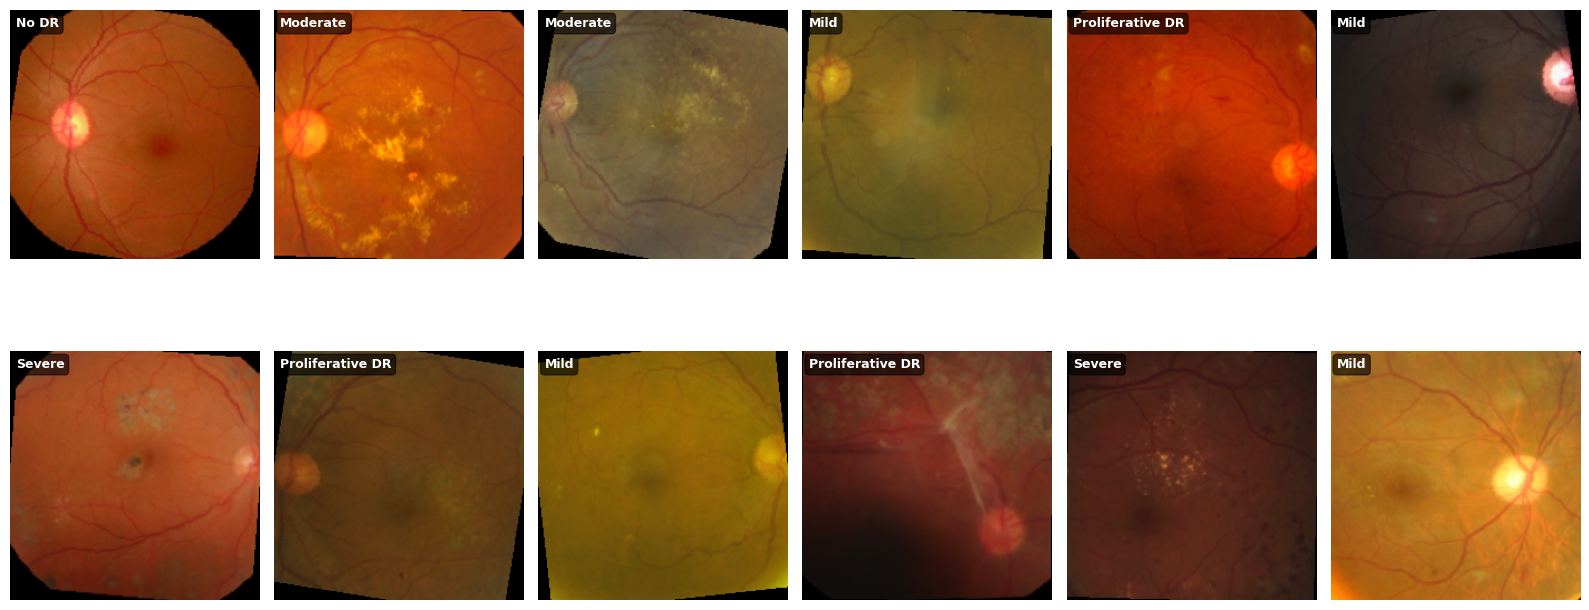

In [ ]:
# Visualization function for batch
def show_batch(images, labels, n=12, ncols=6):
    """Visualize a batch of training images with labels."""
    nrows = int(np.ceil(n / ncols))
    plt.figure(figsize=(16, 8))
    
    names_list = [class_names[k] for k in sorted(class_names.keys())]
    
    for i in range(min(n, len(images))):
        ax = plt.subplot(nrows, ncols, i + 1)
        img = denorm(images[i].cpu()).permute(1, 2, 0).numpy()
        img = np.clip(img, 0, 1)
        
        plt.imshow(img)
        ax.axis('off')
        
        label_text = names_list[int(labels[i])]
        ax.text(
            5, 15, label_text,
            color='white', fontsize=9, weight='bold',
            bbox=dict(boxstyle='round,pad=0.3', fc='black', alpha=0.6)
        )
    
    plt.tight_layout()
    plt.show()

# Show a sample batch
inputs, labels = next(iter(train_loader))
show_batch(inputs, labels, n=12, ncols=6)


## 6. EfficientNet-B0 Model Definition


In [ ]:
# Load EfficientNet-B0 with ImageNet pretrained weights
weights = EfficientNet_B0_Weights.IMAGENET1K_V1
model = efficientnet_b0(weights=weights)

# Replace classifier for 5-class DR
# EfficientNet classifier is a Sequential: [Dropout, Linear]
in_feats = model.classifier[1].in_features
model.classifier[1] = nn.Linear(in_feats, NUM_CLASSES)

# Optionally freeze features initially (uncomment to use)
# for p in model.features.parameters():
#     p.requires_grad = False

# Move model to device
model = model.to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Model: EfficientNet-B0")
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Frozen parameters: {total_params - trainable_params:,}")


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /Users/smridhipatwari/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth
100%|██████████| 20.5M/20.5M [00:00<00:00, 38.7MB/s]

Model: EfficientNet-B0
Total parameters: 4,013,953
Trainable parameters: 4,013,953
Frozen parameters: 0


## 7. Loss, Optimizer, Scheduler, wandb Setup


In [ ]:
# Loss function
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor, label_smoothing=0.05)

# Optimizer
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)

# Training epochs
TOTAL_EPOCHS = 25

# Scheduler
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=TOTAL_EPOCHS, eta_min=1e-6
)

print("Training setup:")
print(f"  Loss: CrossEntropyLoss (label_smoothing=0.05)")
print(f"  Optimizer: AdamW (lr=1e-4, weight_decay=1e-4)")
print(f"  Scheduler: CosineAnnealingLR (T_max={TOTAL_EPOCHS}, eta_min=1e-6)")
print(f"  Total epochs: {TOTAL_EPOCHS}")


Training setup:
  Loss: CrossEntropyLoss (label_smoothing=0.05)
  Optimizer: AdamW (lr=1e-4, weight_decay=1e-4)
  Scheduler: CosineAnnealingLR (T_max=25, eta_min=1e-6)
  Total epochs: 25


In [ ]:
# Weights & Biases login
wandb.login()


wandb: Currently logged in as: smridhip (smridhip-carnegie-mellon-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [ ]:
# Initialize wandb run
wandb.init(
    project="retinexplain-dr",
    name="efficientnet_b0-aptos",
    group="dr-model-comparison",
    config={
        "model": "efficientnet_b0",
        "img_size": IMG_SIZE,
        "batch_size": BATCH_SIZE,
        "total_epochs": TOTAL_EPOCHS,
        "optimizer": "AdamW",
        "scheduler": "CosineAnnealingLR",
        "loss": "CrossEntropy + label_smoothing",
    }
)

# Watch model
wandb.watch(model, log="all", log_freq=100)

print("Weights & Biases initialized")


Weights & Biases initialized


## 8. Training & Evaluation Helpers


In [ ]:
# Helper functions
def get_current_lrs(optimizer):
    """Get current learning rates for all parameter groups."""
    return [group['lr'] for group in optimizer.param_groups]

def predict_all(model, loader, device):
    """Get all predictions and true labels from a dataloader."""
    model.eval()
    y_true = []
    y_pred = []
    
    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())
    
    return np.array(y_true), np.array(y_pred)

def evaluate_accuracy(model, loader):
    """Compute accuracy on a dataloader."""
    y_true, y_pred = predict_all(model, loader, device)
    return (y_true == y_pred).mean()


In [ ]:
# Main training function
def train_model(model, dataloaders, dataset_sizes, criterion, optimizer, scheduler, num_epochs, class_names, best_model_path):
    """Train the model and return history."""
    
    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": [],
        "train_f1": [],
        "val_f1": [],
        "lr": [],
    }
    
    best_val_f1 = 0.0
    
    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs}")
        print("-" * 60)
        
        # Each epoch has a training and validation phase
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()
            
            running_loss = 0.0
            running_corrects = 0
            all_labels = []
            all_preds = []
            
            # Iterate over data
            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)
                
                # Zero gradients
                optimizer.zero_grad()
                
                # Forward pass
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)
                    
                    # Backward pass only in training
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()
                
                # Statistics
                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)
                all_labels.extend(labels.cpu().numpy())
                all_preds.extend(preds.cpu().numpy())
            
            # Update scheduler after training phase
            if phase == 'train':
                scheduler.step()
            
            # Compute epoch metrics
            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]
            epoch_f1 = f1_score(all_labels, all_preds, average='macro')
            
            # Store history
            history[f"{phase}_loss"].append(epoch_loss)
            history[f"{phase}_acc"].append(epoch_acc.item())
            history[f"{phase}_f1"].append(epoch_f1)
            
            # Log to wandb
            wandb.log({
                f"{phase}_loss": epoch_loss,
                f"{phase}_acc": epoch_acc.item(),
                f"{phase}_f1": epoch_f1,
                "epoch": epoch + 1,
            })
            
            # Log learning rate
            if phase == 'train':
                current_lrs = get_current_lrs(optimizer)
                history["lr"].append(current_lrs[0])
                wandb.log({"lr": current_lrs[0], "epoch": epoch + 1})
            
            print(f"{phase.capitalize()} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f} F1: {epoch_f1:.4f}")
            
            # Save best model based on validation F1
            if phase == 'val' and epoch_f1 > best_val_f1:
                best_val_f1 = epoch_f1
                torch.save(model.state_dict(), best_model_path)
                print(f"Saved best model (val_f1: {best_val_f1:.4f})")
    
    return model, history


## 9. Run Training & Final Metrics


In [ ]:
# Model save path - save to local models directory
MODELS_DIR = os.path.join(PROJECT_ROOT, "models")
os.makedirs(MODELS_DIR, exist_ok=True)
BEST_MODEL_PATH = os.path.join(MODELS_DIR, "efficientnet_b0_best.pt")
print(f"Model will be saved to: {BEST_MODEL_PATH}")

# Run training
print("Starting training...")
model, history = train_model(
    model=model,
    dataloaders=dataloaders,
    dataset_sizes=dataset_sizes,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    num_epochs=TOTAL_EPOCHS,
    class_names=class_names,
    best_model_path=BEST_MODEL_PATH,
)

print("\nTraining complete!")


Model will be saved to: /Users/smridhipatwari/Projects/retinxplain/models/efficientnet_b0_best.pt
Starting training...

Epoch 1/25
------------------------------------------------------------


KeyboardInterrupt: 

Error in callback <bound method _WandbInit._post_run_cell_hook of <wandb.sdk.wandb_init._WandbInit object at 0x357ddef90>> (for post_run_cell), with arguments args (<ExecutionResult object at 171be0350, execution_count=24 error_before_exec=None error_in_exec= info=<ExecutionInfo object at 378b2f950, raw_cell="# Model save path - save to local models directory.." transformed_cell="# Model save path - save to local models directory.." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell:/Users/smridhipatwari/Projects/retinxplain/Notebooks/efficientnet_b0_RetinXplain_cleaned.ipynb#X45sZmlsZQ%3D%3D> result=None>,),kwargs {}:


ConnectionResetError: Connection lost

In [ ]:
# Load best model weights
model.load_state_dict(torch.load(BEST_MODEL_PATH))
print("Loaded best model weights")


In [ ]:
# Evaluate on test set
print("Evaluating on test set...")
y_true_test, y_pred_test = predict_all(model, test_loader, device)

test_acc = (y_true_test == y_pred_test).mean()
test_f1 = f1_score(y_true_test, y_pred_test, average='macro')

print(f"\nTest Accuracy: {test_acc:.4f}")
print(f"Test Macro-F1: {test_f1:.4f}")

# Classification report
print("\nClassification Report:")
print(classification_report(y_true_test, y_pred_test, target_names=[class_names[i] for i in range(5)]))

# Log to wandb
wandb.log({
    "test_acc": test_acc,
    "test_f1": test_f1,
})


In [ ]:
# Confusion matrix
cm = confusion_matrix(y_true_test, y_pred_test)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# Plot confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=[class_names[i] for i in range(5)],
            yticklabels=[class_names[i] for i in range(5)])
axes[0].set_title('Confusion Matrix (Counts)')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# Normalized
sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues', ax=axes[1],
            xticklabels=[class_names[i] for i in range(5)],
            yticklabels=[class_names[i] for i in range(5)])
axes[1].set_title('Confusion Matrix (Normalized)')
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()

# Log to wandb
wandb.log({"confusion_matrix": wandb.Image(fig)})
plt.close()


In [ ]:
# Plot training curves
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Loss
axes[0].plot(history['train_loss'], label='Train Loss', marker='o')
axes[0].plot(history['val_loss'], label='Val Loss', marker='s')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training and Validation Loss')
axes[0].legend()
axes[0].grid(True)

# Accuracy
axes[1].plot(history['train_acc'], label='Train Acc', marker='o')
axes[1].plot(history['val_acc'], label='Val Acc', marker='s')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Training and Validation Accuracy')
axes[1].legend()
axes[1].grid(True)

# Learning rate
axes[2].plot(history['lr'], label='Learning Rate', marker='o', color='green')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Learning Rate')
axes[2].set_title('Learning Rate Schedule')
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()

# Log to wandb
wandb.log({"training_curves": wandb.Image(fig)})
plt.close()


## 10. Grad-CAM++ for EfficientNet-B0


In [ ]:
# Setup Grad-CAM++ for EfficientNet-B0
# Target layer: last feature block
target_layers = [model.features[-1]]
cam = GradCAMPlusPlus(model=model, target_layers=target_layers)

print("Grad-CAM++ initialized for EfficientNet-B0")
print(f"Target layer: {target_layers[0]}")


In [ ]:
# Function to get Grad-CAM++ for a specific index
def get_gradcam_for_index(ds_idx, df, images_root, model, device, mode="pred"):
    """
    Get Grad-CAM++ visualization for a specific dataset index.
    
    Args:
        ds_idx: Index in the dataframe
        df: DataFrame with 'id_code' and 'diagnosis'
        images_root: Root directory for images
        model: Trained model
        device: Device to run on
        mode: "pred" to explain predicted class, "true" to explain true class
    
    Returns:
        fundus_np: Original fundus image (numpy array, [0,1])
        gradcam_overlay: Grad-CAM++ overlay (numpy array, [0,1])
        true_label: True label
        pred_label: Predicted label
        target_class: Class being explained
    """
    # Get image ID and true label
    img_id = str(df.iloc[ds_idx]['id_code'])
    true_label = int(df.iloc[ds_idx]['diagnosis'])
    
    # Load raw image
    img_path = os.path.join(images_root, f"{img_id}.png")
    if not os.path.exists(img_path):
        img_path = os.path.join(images_root, f"{img_id}.jpg")
    
    raw_img = Image.open(img_path).convert("RGB")
    
    # Apply SmartFundusCrop and convert to numpy [0,1]
    crop_transform = SmartFundusCrop()
    cropped_img = crop_transform(raw_img)
    fundus_np = np.array(cropped_img).astype(np.float32) / 255.0
    
    # Apply validation transform for model input
    input_tensor = data_transforms["val"](cropped_img).unsqueeze(0).to(device)
    
    # Forward pass
    model.eval()
    with torch.no_grad():
        logits = model(input_tensor)
        probs = F.softmax(logits, dim=1)
        _, pred_label = torch.max(logits, 1)
        pred_label = pred_label.item()
    
    # Choose target class
    if mode == "pred":
        target_class = pred_label
    else:
        target_class = true_label
    
    # Get Grad-CAM++
    targets = [ClassifierOutputTarget(target_class)]
    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)
    grayscale_cam = grayscale_cam[0, :]
    
    # Resize CAM to fundus size
    h, w = fundus_np.shape[:2]
    grayscale_cam_resized = cv2.resize(grayscale_cam, (w, h))
    
    # Overlay
    gradcam_overlay = show_cam_on_image(fundus_np, grayscale_cam_resized, use_rgb=True)
    gradcam_overlay = gradcam_overlay.astype(np.float32) / 255.0
    
    return fundus_np, gradcam_overlay, true_label, pred_label, target_class


In [ ]:
# Visualize Grad-CAM++ for a few examples
n_examples = 3
indices = random.sample(range(len(val_df)), n_examples)

fig, axes = plt.subplots(n_examples, 2, figsize=(10, 3*n_examples))
if n_examples == 1:
    axes = axes.reshape(1, -1)

for i, ds_idx in enumerate(indices):
    fundus_np, gradcam_overlay, true_label, pred_label, target_class = get_gradcam_for_index(
        ds_idx, val_df, val_images, model, device, mode="pred"
    )
    
    # Original
    axes[i, 0].imshow(fundus_np)
    axes[i, 0].set_title(f"Original\nTrue: {class_names[true_label]}, Pred: {class_names[pred_label]}")
    axes[i, 0].axis('off')
    
    # Grad-CAM++
    axes[i, 1].imshow(gradcam_overlay)
    axes[i, 1].set_title(f"Grad-CAM++ (Class: {class_names[target_class]})")
    axes[i, 1].axis('off')

plt.tight_layout()
plt.show()

# Log to wandb
wandb.log({"gradcam_examples": wandb.Image(fig)})
plt.close()


## 11. LIME for EfficientNet-B0


In [ ]:
# Initialize LIME explainer
explainer = lime_image.LimeImageExplainer()
print("LIME explainer initialized")


In [ ]:
# Prediction function for LIME
def lime_predict(images_np, model, device, data_transforms):
    """
    Prediction function for LIME.
    
    Args:
        images_np: List/array of images as numpy arrays (H, W, 3) in [0,1] or [0,255]
        model: Trained model
        device: Device to run on
        data_transforms: Transform to apply
    
    Returns:
        probs: Probability predictions (N, num_classes)
    """
    model.eval()
    batch_tensors = []
    
    for img in images_np:
        # Ensure [0,1] range
        if img.max() > 1.0:
            img = img.astype(np.float32) / 255.0
        
        # Convert to PIL
        img_pil = Image.fromarray((img * 255).astype(np.uint8))
        
        # Apply transform
        img_tensor = data_transforms(img_pil).unsqueeze(0)
        batch_tensors.append(img_tensor)
    
    # Stack and move to device
    batch = torch.cat(batch_tensors, dim=0).to(device)
    
    # Forward pass
    with torch.no_grad():
        logits = model(batch)
        probs = F.softmax(logits, dim=1)
    
    return probs.cpu().numpy()


In [ ]:
# Function to get LIME explanation
def get_lime_for_fundus(fundus_np, pred_label, model, device, data_transforms, num_features=8, num_samples=200):
    """
    Get LIME explanation for a fundus image.
    
    Args:
        fundus_np: Fundus image as numpy array (H, W, 3) in [0,1]
        pred_label: Predicted label
        model: Trained model
        device: Device to run on
        data_transforms: Transform to apply
        num_features: Number of features to highlight
        num_samples: Number of LIME samples
    
    Returns:
        lime_overlay: LIME overlay visualization
    """
    explanation = explainer.explain_instance(
        fundus_np,
        lambda imgs: lime_predict(imgs, model, device, data_transforms),
        top_labels=5,
        num_samples=num_samples,
        hide_color=0,
    )
    
    temp, mask = explanation.get_image_and_mask(
        pred_label,
        positive_only=True,
        num_features=num_features,
        hide_rest=False,
    )
    
    # Ensure [0,1] range
    if temp.max() > 1:
        temp = temp.astype(np.float32) / 255.0
    
    lime_overlay = mark_boundaries(temp, mask)
    
    return lime_overlay


In [ ]:
# Combined visualization function
def visualize_explanations(n_examples=3):
    """Visualize original, Grad-CAM++, and LIME for multiple examples."""
    indices = random.sample(range(len(val_df)), n_examples)
    
    fig, axes = plt.subplots(n_examples, 3, figsize=(15, 5*n_examples))
    if n_examples == 1:
        axes = axes.reshape(1, -1)
    
    for i, ds_idx in enumerate(indices):
        # Get Grad-CAM++
        fundus_np, gradcam_overlay, true_label, pred_label, target_class = get_gradcam_for_index(
            ds_idx, val_df, val_images, model, device, mode="pred"
        )
        
        # Get LIME
        lime_overlay = get_lime_for_fundus(
            fundus_np, pred_label, model, device, data_transforms["val"],
            num_features=8, num_samples=200
        )
        
        # Original
        axes[i, 0].imshow(fundus_np)
        axes[i, 0].set_title(f"Original\nTrue: {class_names[true_label]}\nPred: {class_names[pred_label]}")
        axes[i, 0].axis('off')
        
        # Grad-CAM++
        axes[i, 1].imshow(gradcam_overlay)
        axes[i, 1].set_title(f"Grad-CAM++\n(Class: {class_names[target_class]})")
        axes[i, 1].axis('off')
        
        # LIME
        axes[i, 2].imshow(lime_overlay)
        axes[i, 2].set_title(f"LIME\n(Class: {class_names[pred_label]})")
        axes[i, 2].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # Log to wandb
    wandb.log({"combined_explanations": wandb.Image(fig)})
    plt.close()

# Run visualization
print("Generating combined explainability visualizations...")
visualize_explanations(n_examples=3)
print("Done!")


In [ ]:
# Finish wandb run
wandb.finish()
print("Weights & Biases run completed!")
